# Stats and visuals for the public spine

This is a pdf generated from a notebook, using the most recent version of the public spine. If anything is useful the graphs can be saved as pngs and accessed directly.

In [2]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot
import upsetplot


In [3]:
basefilename = '/Users/fionack/Projects/TSO_project/public_spine_data/public_spine'
#basefilename = '/Users/fionack/Projects/TSO_project/tso-database-builder/main_spine.ccew.oscr.ccni.ch.csv'#main_spine.ccew.oscr'
spine_df = pd.read_csv(basefilename+'.spine.csv',usecols=['uid','normalisedname'])
extras_df = pd.read_csv(basefilename+'.supplementary.csv',usecols=['uid','normalisedname','source'])
matches_df = pd.read_csv(basefilename+'.matches.csv',low_memory=False)

print(f'There are {spine_df.shape[0]} rows in the main spine, {extras_df.shape[0]} rows of supplementary data and {matches_df.shape[0]} matches found.\n')

There are 758054 rows in the main spine, 1082963 rows of supplementary data and 85565 matches found.



## Counts per source in main spine

basesource
COH     379825
CHC     346390
MPR      20498
NIC       7746
SC        2704
COOP       720
SHR        159
SHPE        12
Name: count, dtype: int64
source_codes = {'COH', 'SC', 'CHC', 'NIC', 'SHPE', 'COOP', 'MPR', 'SHR'}


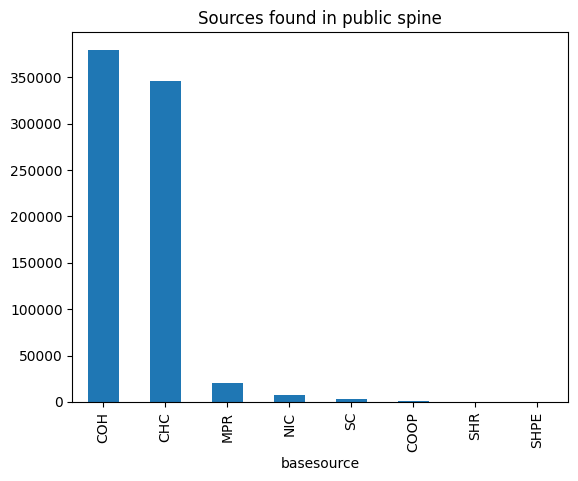

In [4]:
spine_df['basesource'] = spine_df.apply(lambda row: row['uid'].split('-')[1], axis=1)

source_counts = spine_df['basesource'].value_counts(dropna=False)
source_counts = source_counts.rename(index={np.nan: 'NaN'})
print(source_counts)
print(f"source_codes = {set(spine_df['basesource'])}")
source_counts.plot(kind='bar')
pyplot.title('Sources found in public spine')
pyplot.savefig('%s.feb2025.sources.png'%basefilename)


basesource
CHC     247360
COH     211625
MPR      11515
SHPE      1322
CQC        976
COOP       725
NIC        631
SC          31
SHR          5
CIS          1
Name: count, dtype: int64


Text(0.5, 1.0, 'Sources found in supplementary data')

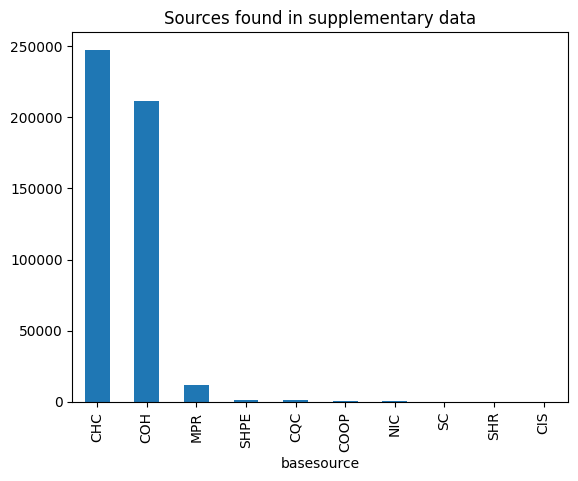

In [5]:
extras_df['basesource'] = extras_df.apply(lambda row: row['uid'].split('-')[1], axis=1)

extras_sources = extras_df[['uid','basesource']].drop_duplicates()
extras_source_counts = extras_sources['basesource'].value_counts(dropna=False)
print(extras_source_counts)
extras_source_counts = extras_source_counts.rename(index={np.nan: 'NaN'})
extras_source_counts.plot(kind='bar')
pyplot.title('Sources found in supplementary data')


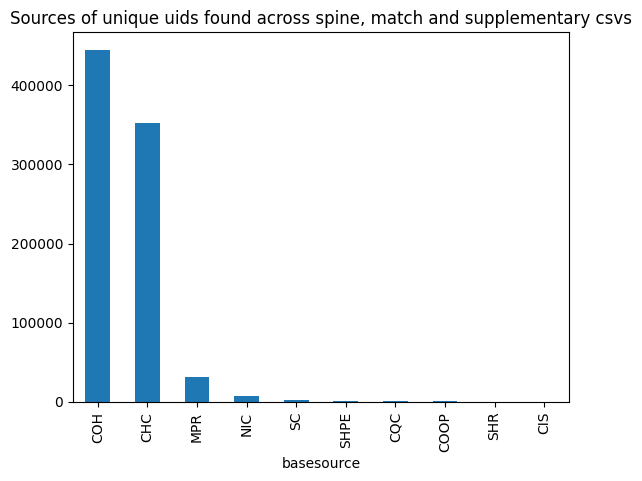

In [6]:
# find all uids used across all data:
uid_set = set(list(spine_df['uid']) + list(matches_df['orgA_uid']) + list(matches_df['orgB_uid']) + list(extras_df['uid']))

all_df = pd.DataFrame(uid_set,columns=['uid'])
#print(all_df)
all_df['basesource'] = all_df.apply(lambda row: row['uid'].split('-')[1], axis=1)

source_counts = all_df['basesource'].value_counts(dropna=False)
source_counts = source_counts.rename(index={np.nan: 'NaN'})
#print(source_counts)
source_counts.plot(kind='bar')


pyplot.title('Sources of unique uids found across spine, match and supplementary csvs')

pyplot.savefig('%s.all.sources.png'%basefilename)


source_counts = [f"{source} & {count} \\\\ \\hline\n" for source, count in source_counts.items()]

with open(basefilename+'.all_used_orgs.tab.tex', 'w') as ofile:

    ofile.write('\\begin{table}[h]\n  \\centering\n')
    ofile.write('\\begin{tabular}{|l|r|}\n    \\hline\n')
    ofile.write('Source & Count of orgs \\\\ \\hline \\hline\n')

    for i in source_counts:
        ofile.write(i)

    ofile.write('\\end{tabular}\n')
    ofile.write('\\caption{Count of organisations per source}\n')
    ofile.write('\\label{tab:all_used_orgs}\n')
    ofile.write('\\end{table}\n')



                 match_type  count
0                       ftc  53494
1  companyid - id_in_source  29349
2               name - care   1140
3   companyid - coop mutual    749
4            name - housing    725
5     companyid - companyid     75
6        name - crossborder     33


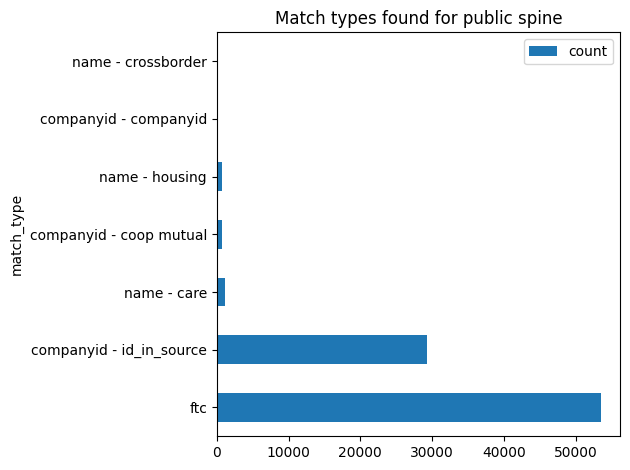

In [7]:

match_types = matches_df['match_type'].value_counts(dropna=False)
match_types = match_types.rename(index={np.nan: 'NaN'})
match_types = match_types.reset_index()
match_types.columns = ['match_type','count']

print(match_types)
match_types.plot(y='count', x='match_type', kind='barh')
pyplot.title('Match types found for public spine')
pyplot.tight_layout()
pyplot.savefig('%s.matchtypes.png'%basefilename)
pyplot.show()
# also think of how to plot this so that identical matches are shown in a different way - pairs of organisations which are matched by ftc and also name, for example - this chart doesn't differentiate



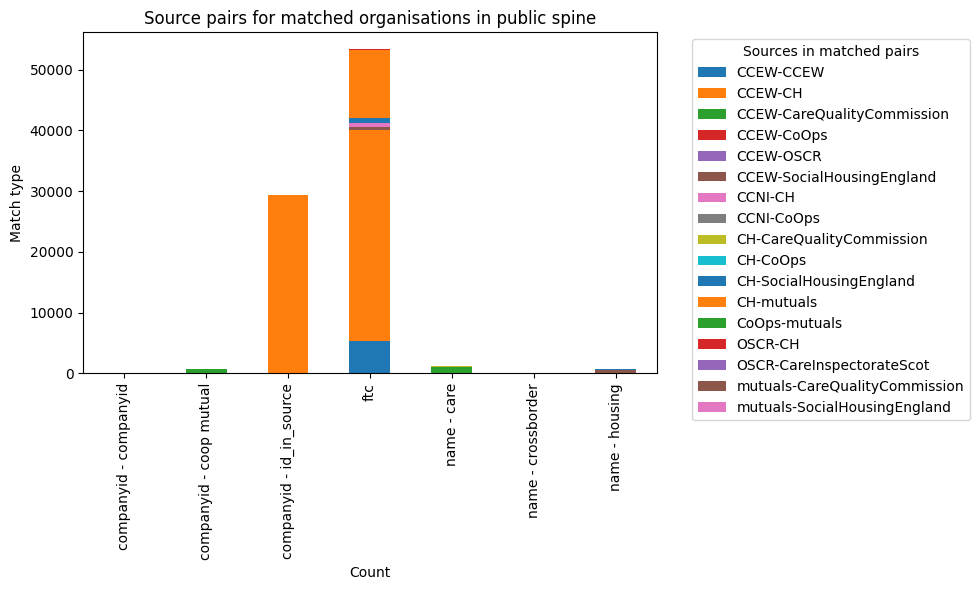

<Figure size 640x480 with 0 Axes>

In [8]:
matches_df['source-source'] = matches_df.apply(lambda row: '%s-%s'%(row['orgA_source'],row['orgB_source']), axis=1)
match_types = matches_df.groupby('match_type')['source-source'].value_counts(dropna=False)
match_types = match_types.rename(index={np.nan: 'NaN'})

# Convert Series to DataFrame for plotting
match_types = match_types.unstack().fillna(0)

# Plot the data
match_types.plot(kind='bar', stacked=True, figsize=(10, 6))
pyplot.title('Source pairs for matched organisations in public spine')
pyplot.legend(title='Sources in matched pairs', bbox_to_anchor=(1.05, 1), loc='upper left')
pyplot.xlabel('Count')
pyplot.ylabel('Match type')
pyplot.tight_layout()
pyplot.show()
pyplot.savefig('%s.match_source_pairs.types.png'%basefilename)

In [9]:
uids_in_matches_df = set(matches_df['orgA_uid'] + matches_df['orgB_uid'])
print(f'Unique uids in matches csv = {len(uids_in_matches_df)}')
print(f"Unique uids in main spine csv = {len(set(spine_df['uid']))}")

orga_uids = set(matches_df['orgA_uid'])
orgb_uids = set(matches_df['orgB_uid'])

print(f'Number of unique organisations in position OrgA = {len(orga_uids)}, and unique OrgB uids = {len(orgb_uids)}')

Unique uids in matches csv = 84899
Unique uids in main spine csv = 758054
Number of unique organisations in position OrgA = 78121, and unique OrgB uids = 84018


In [55]:
# code to generate the table used in release_info.tex
# with columns source  &  count in   &  count in     &  count in \\
#                      &  spine.csv  &  matches.csv  &  matches.csv \\


# Initialize an empty list to store the results
table_data = []

spine_df['basesource'] = spine_df.apply(lambda row: row['uid'].split('-')[1], axis=1)

matches_uids_df = pd.DataFrame(set(list(matches_df['orgA_uid'])+list(matches_df['orgB_uid'])),columns=['uid'])

matches_uids_df['basesource'] = matches_uids_df.apply(lambda row: row['uid'].split('-')[1], axis=1)


for source in ['CHC','SC','NIC','COH','COOP','MPR','SHR','SHPE','CIS','CQC']:
    # Get unique UIDs for the source in both dataframes
    spine_uids = spine_df.loc[spine_df['basesource'] == source, 'uid'].unique()
    matches_uids = matches_uids_df.loc[matches_uids_df['basesource'] == source, 'uid'].unique()

    # Calculate counts
    count_in_spine = len(spine_uids)
    count_in_matches = len(matches_uids)
    count_in_matches_not_spine = len(set(matches_uids) - set(spine_uids))

    # Append the data for the source
    table_data.append([source, count_in_spine, count_in_matches, count_in_matches_not_spine])


rows=[f'{i[0]} & {i[1]} & {i[2]} & {i[3]} \\\\' for i in table_data]

latex_table = (
    "\\begin{table}[h]\n"
    "\\centering\n"
    "\\begin{tabularx}{0.6\\textwidth}{|X|r|r|r|}\n"
    "\\hline\n"
    "source & count in & count in & count in \\\\\n"
    "& spine.csv &  matches.csv &  matches.csv \\\\\n"
    "&&& not spine.csv \\\\\n"
    +'\n'.join(rows)
    +"\\hline\n"
    "\\end{tabularx}\n"
    "\\caption{Counts of unique uids in 10-12-2024 spine and matches csvs}\n"
    "\\end{table}\n"
)

# Print the LaTeX table


print(latex_table)





\begin{table}[h]
\centering
\begin{tabularx}{0.6\textwidth}{|X|r|r|r|}
\hline
source & count in & count in & count in \\
& spine.csv &  matches.csv &  matches.csv \\
&&& not spine.csv \\
CHC & 336597 & 72847 & 5393 \\
SC & 49278 & 10171 & 1374 \\
NIC & 7746 & 659 & 0 \\
COH & 361512 & 87812 & 75028 \\
COOP & 9236 & 9978 & 1326 \\
MPR & 18649 & 13036 & 13024 \\
SHR & 158 & 15 & 0 \\
SHPE & 9 & 1311 & 1311 \\
CIS & 0 & 1879 & 1879 \\
CQC & 0 & 975 & 975 \\\hline
\end{tabularx}
\caption{Counts of unique uids in 10-12-2024 spine and matches csvs}
\end{table}



Find the numbers of matches found by any combination of match types:

In [10]:
match_types_dict = {}  #
uid_uid_match_dict = {}
#print(matches_df)                   
matches_df['uid-uid'] = matches_df.apply(lambda row: '%s:%s' % tuple(sorted([row['orgA_uid'], row['orgB_uid']])), axis=1)
#print(matches_df)
#
unique_uidA_uidB = set(matches_df['uid-uid'])
#print(unique_uidA_uidB)
print(f'Number of uniquely matched pairs of orgs in matches csv = {len(unique_uidA_uidB)} (of {matches_df.shape[0]} rows in matches csv)')
print(f' ==> number of org pairs found in multiple ways = {matches_df.shape[0]-len(unique_uidA_uidB)}')
#matches_df['uid-uid'].value_counts()



Number of uniquely matched pairs of orgs in matches csv = 109363 (of 110062 rows in matches csv)
 ==> number of org pairs found in multiple ways = 699


In [11]:
import pandas as pd
import os
from matplotlib import pyplot as plt
import upsetplot
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


source_order = {'CHC': 1, 
                'SC' : 2,
                'NIC': 3, 
                'COH' : 4,
                'COOP' : 5,
                'MPR' : 6,
                'SHR' : 7,
                'SHPE' : 8,
                'CIS' : 9,
                'CQC' : 10 }

def plot_upset_matches_multi(basefilename,include = 'all'):#_unmatched_orgs=True,only_unmatched_orgs=False):
    if not include in ['all','only_matched','only_unmatched']:
        raise ValueError("Invalid argument for include, must be in ['all','only_matched','only_unmatched']")

    # Read input files
    #all_uids = pd.read_csv(basefilename + '.spine.csv', usecols=['uid'])
    #matches_df = pd.read_csv(basefilename + '.matches.csv')

    all_uids = pd.read_csv(basefilename + '.spine.csv', usecols=['uid'], dtype={'uid': str})
    matches_df = pd.read_csv(basefilename + '.matches.csv', usecols=['orgA_uid','orgB_uid'],dtype=str, low_memory=False)

    
    # Create a dictionary to map each uid to its matches
    match_dict = {}
    

    for index, row in matches_df.iterrows():
        orgA_uid, orgB_uid = row['orgA_uid'], row['orgB_uid']
        if orgA_uid not in match_dict:
            match_dict[orgA_uid] = set()
        if orgB_uid not in match_dict:
            match_dict[orgB_uid] = set()
        match_dict[orgA_uid].add(orgB_uid)
        match_dict[orgB_uid].add(orgA_uid)
    
    def find_matches(uid):
        # Use an iterative approach to find all matches
        found = set()
        stack = [uid]
        while stack:
            current = stack.pop()
            if current not in found:
                found.add(current)
                stack.extend(match_dict.get(current, []))
        return found
    
    # Process each uid and find all matched uids
    m_list = []
    for uid in all_uids['uid']:
        matched = find_matches(uid)
        matched.add(uid)
        try:
            sources = [i.split('-')[1] for i in matched]
            m_list.append(sources)
        except Exception as e:
            print(f'{e}: uid = {uid}, matched = {matched}')
    
    # Create a DataFrame for the upset plot
    series = pd.Series(m_list)
    source_list = list(source_order.keys())
    df = pd.DataFrame({item: series.apply(lambda x: item in x) for item in source_list})
    
    # Group by source_list and get the size
    df_grouped = df.groupby(source_list).size()
    
    if include == 'only_matched':
    # Filter out rows with only one 'true' value
        df_grouped = df_grouped[df_grouped.index.map(sum) > 1]

    if include == 'only_unmatched':
        df_grouped = df_grouped[df_grouped.index.map(sum) ==1]
    
    
    # Plot using upsetplot
    upsetplot.plot(df_grouped, orientation='horizontal')
    if include == 'all':
        plt.title("Data sources used for each organisation found in %s" % os.path.basename(basefilename).replace('_',' ').capitalize())
        plt.savefig('%s.all_orgs.upsetplot.png' % basefilename)
    elif include == 'only_matched':
        plt.title("Data sources for matched organisations only, found in %s" % os.path.basename(basefilename).replace('_',' ').capitalize())
        plt.savefig('%s.matched_orgs.upsetplot.png' % basefilename)
    elif include == 'only_unmatched':
        plt.title("Data sources for organisations found in one source only")
        plt.savefig('%s.unmatched.upsetplot.png' % basefilename)
    
    plt.show()
    return df_grouped




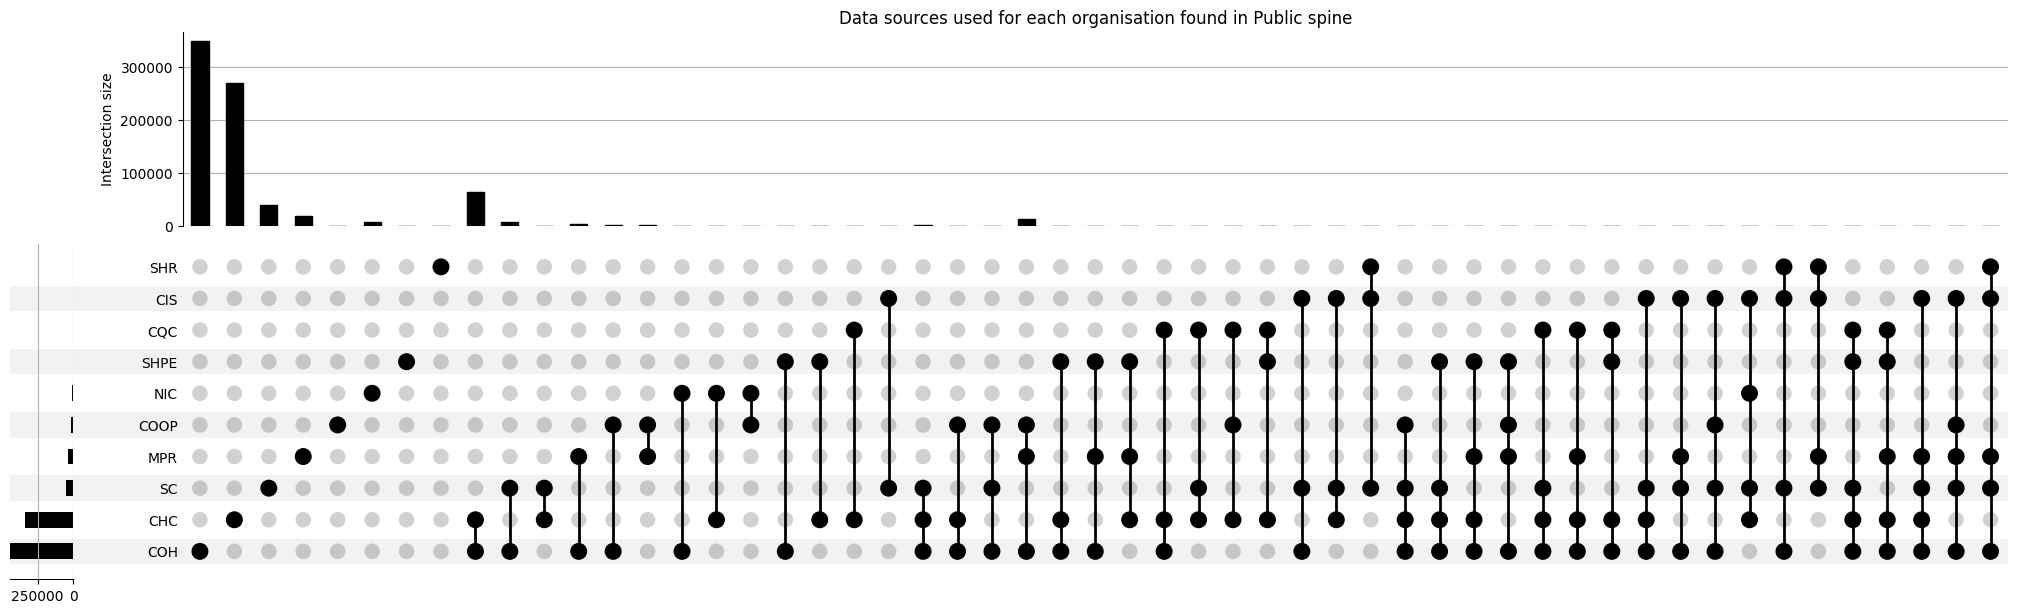

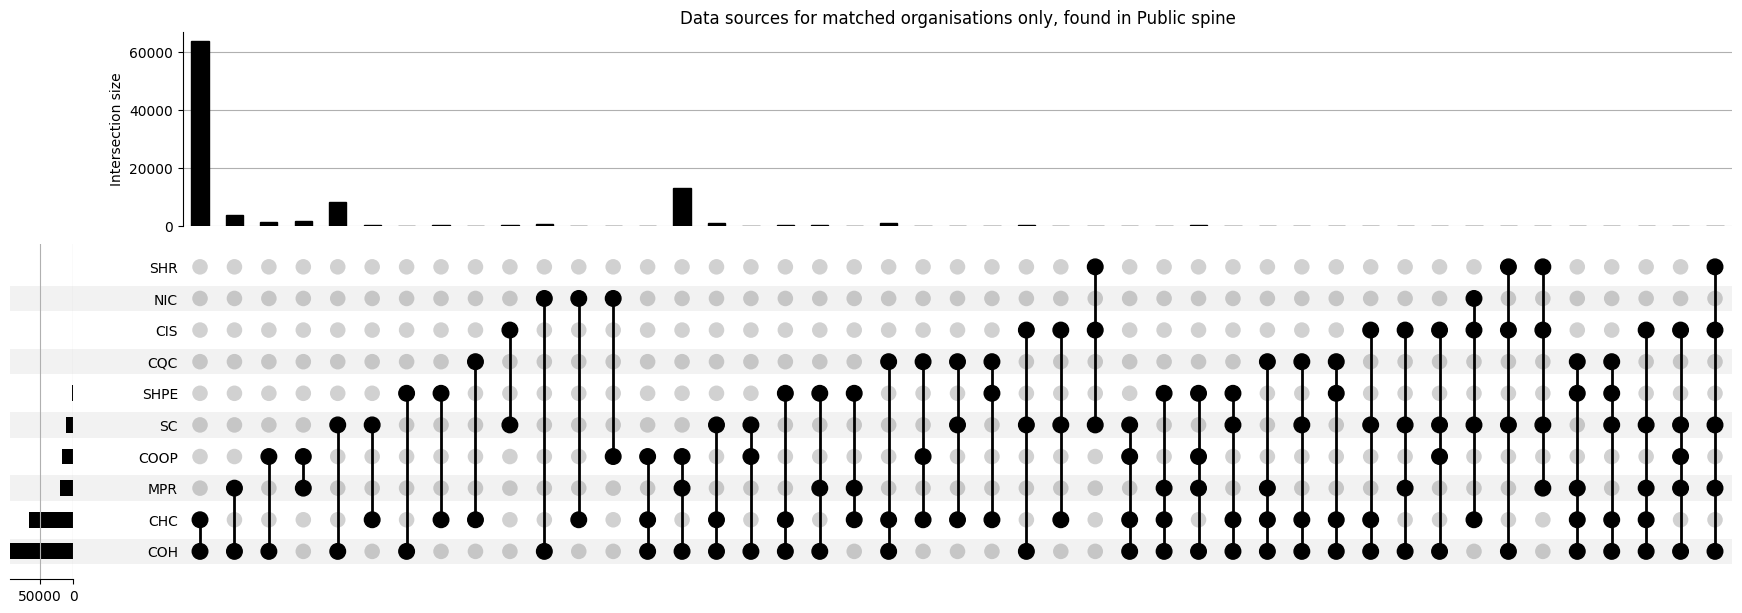

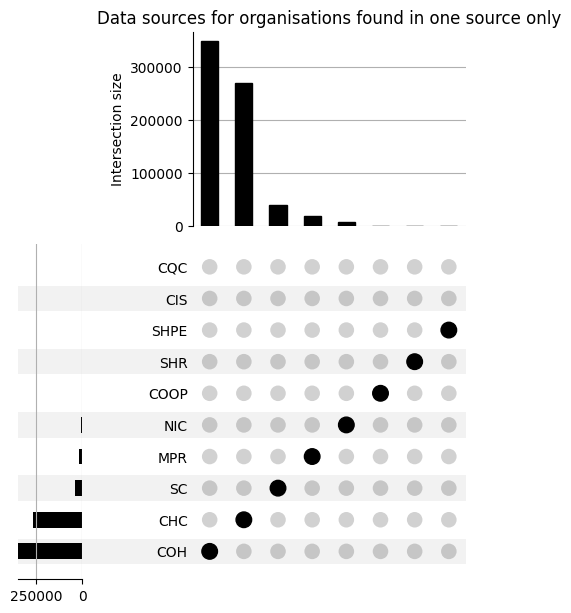

In [12]:
a=plot_upset_matches_multi(basefilename,'all')
b=plot_upset_matches_multi(basefilename,'only_matched')
c=plot_upset_matches_multi(basefilename,'only_unmatched')

Plotting the organisations matched in more than one way through our algorithm:

Text(0, 0.5, 'Count of org pairs matched')

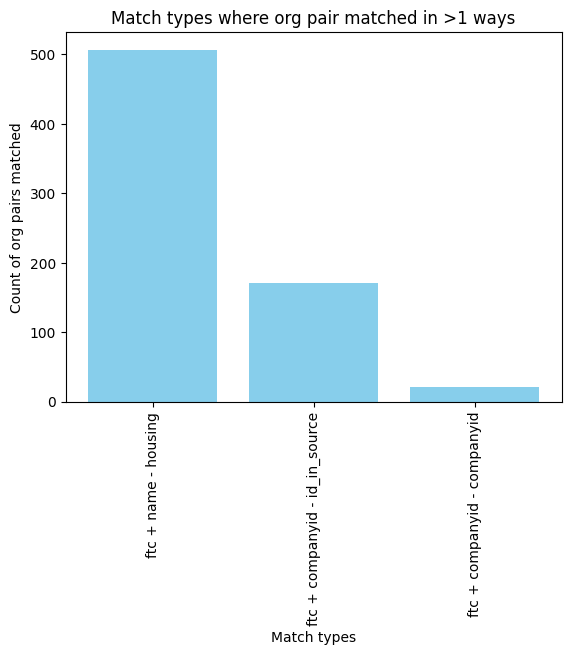

In [13]:

# plot the orgs matched in multiple ways:

def concat_strings(series):
    return ' + '.join(series)


concatenated = matches_df.groupby('uid-uid')['match_type'].apply(concat_strings).reset_index()
concatenated.columns = ['uid-uid','match_type']


counts = matches_df['uid-uid'].value_counts().reset_index()
counts.columns = ['uid-uid', 'count']


result = pd.merge(concatenated, counts, on='uid-uid')

two_matches= result[result['count']>1]
match_type_counts = two_matches['match_type'].value_counts().reset_index()
match_type_counts.columns = ['match_type', 'count']
pyplot.bar(match_type_counts['match_type'], match_type_counts['count'], color='skyblue')
pyplot.xticks(rotation=90)
pyplot.title('Match types where org pair matched in >1 ways')
pyplot.xlabel('Match types')
pyplot.ylabel('Count of org pairs matched')

#pyplot.bar(two_matches['match_type'],height=two_matches.groupby['match_type'].value_counts())



Counts of companies house legal forms. Need to map spine back onto CH data to include the companytype information (this is lost in pre-processing as we only care about overall source at that stage).

In [14]:
raw_ch_df = pd.read_csv('../../raw_data/CH.all.preprocess.csv')

/var/folders/kx/my6qjd410pg_mks04z_5dm3r0000gn/T/ipykernel_25098/226001592.py:1: DtypeWarning: Columns (3,4,8,11) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_ch_df = pd.read_csv('../../raw_data/CH.all.preprocess.csv')


In [15]:

def cic_mapping(s):
    if 'community-interest-company' in s:
        return 'Community Interest Company'
    if 'private-limited-guarant' in s or 'CLG' in s or 'PRI/LTD BY GUAR/NSC' in s or 'PRI/LBG/NSC' in s: 
        return 'Company Limited by Guarantee'
    else: return s

raw_ch_df['compressed_source'] = raw_ch_df['companytype'].apply(cic_mapping)

In [16]:
source_df = raw_ch_df['companytype'].value_counts()
source_df_sorted_by_source = source_df.sort_index()

source_df.sort_index()
print(source_df_sorted_by_source)

companytype
CLG                                                                                           189348
Charitable Incorporated Organisation                                                          346682
Community Interest Company                                                                    358012
Industrial and Provident Society                                                               15366
PRI/LBG/NSC (Private, Limited by guarantee, no share capital, use of 'Limited' exemption)     436013
PRI/LTD BY GUAR/NSC (Private, limited by guarantee, no share capital)                        1212152
Registered Society                                                                            105512
Scottish Charitable Incorporated Organisation                                                  63394
ltd community-interest-company                                                                  9343
plc community-interest-company                                                 

compressed_source
Charitable Incorporated Organisation              346682
Community Interest Company                        449785
Company Limited by Guarantee                     2098810
Industrial and Provident Society                   15366
Registered Society                                105512
Scottish Charitable Incorporated Organisation      63394
Name: count, dtype: int64


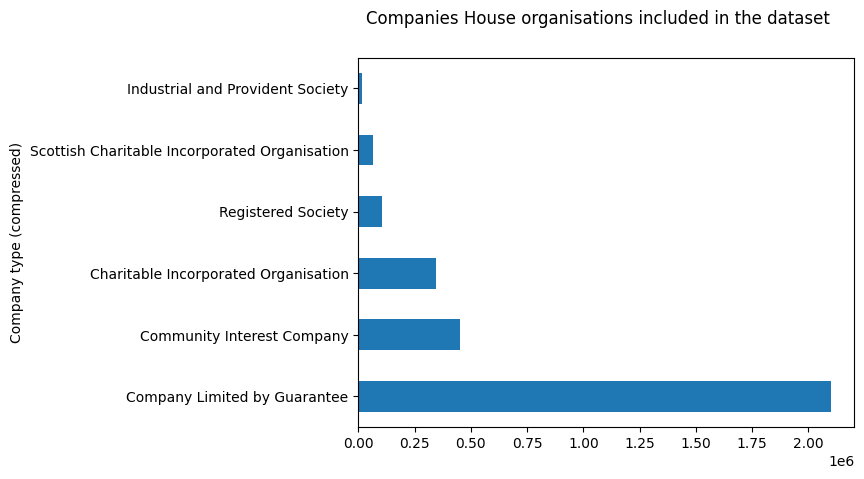

In [17]:
source_df = raw_ch_df['compressed_source'].value_counts()
source_df_sorted_by_source = source_df.sort_index()

source_df.sort_index()
print(source_df_sorted_by_source)
source_df.plot(kind='barh')
pyplot.suptitle('Companies House organisations included in the dataset')
pyplot.ylabel('Company type (compressed)')
pyplot.savefig('../CH_dist.png',bbox_inches='tight')

In [18]:
# preprocessed CH data:
subspine_ch_df = pd.read_csv('../../public_spine_data/CH_all.spine.csv')
supp_ch_df = pd.read_csv('../../public_spine_data/CH_all.spine.supplementary.csv')


/var/folders/kx/my6qjd410pg_mks04z_5dm3r0000gn/T/ipykernel_25098/3635633977.py:2: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  subspine_ch_df = pd.read_csv('../../public_spine_data/CH_all.spine.csv')


In [19]:
len(subspine_ch_df['uid'].unique())

436540

In [20]:
len(supp_ch_df['uid'].unique())

197517

In [21]:
s={'CCEW': 337559, 'OSCR': 49306, 'CCNI': 7745, 'CH': 362311, 'CoOps': 9195, 'mutuals': 18649, 'ScottishHousingRegulator': 158, 'SocialHousingEngland': 9, 'CareInspectorateScot': 1582, 'CareQualityCommission': 35654}
m={'CCEW': 5191, 'CH': 74964, 'SocialHousingEngland': 1981, 'CareQualityCommission': 1376, 'OSCR': 1569, 'CCNI': 1, 'CareInspectorateScot': 2689, 'CoOps': 1368, 'mutuals': 20102}
t=920734